In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pprint
import pyspark
import pyspark.sql.functions as F

from pyspark.sql.functions import col, split
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

import utils.data_processing_bronze_table
import utils.data_processing_gold_table
import seaborn as sns

In [2]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/20 07:02:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/20 07:02:38 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


## set up config

In [3]:
# set up config
snapshot_date_str = "2023-01-01"

start_date_str = "2023-01-01"
end_date_str = "2025-12-01"

In [7]:
# generate list of dates to process
def generate_first_of_month_dates(start_date_str, end_date_str):
    # Convert the date strings to datetime objects
    start_date = datetime.strptime(start_date_str, "%Y-%m-%d")
    end_date = datetime.strptime(end_date_str, "%Y-%m-%d")
    
    # List to store the first of month dates
    first_of_month_dates = []

    # Start from the first of the month of the start_date
    current_date = datetime(start_date.year, start_date.month, 1)

    while current_date <= end_date:
        # Append the date in yyyy-mm-dd format
        first_of_month_dates.append(current_date.strftime("%Y-%m-%d"))
        
        # Move to the first of the next month
        if current_date.month == 12:
            current_date = datetime(current_date.year + 1, 1, 1)
        else:
            current_date = datetime(current_date.year, current_date.month + 1, 1)

    return first_of_month_dates

dates_str_lst = generate_first_of_month_dates(start_date_str, end_date_str)
dates_str_lst

['2023-01-01',
 '2023-02-01',
 '2023-03-01',
 '2023-04-01',
 '2023-05-01',
 '2023-06-01',
 '2023-07-01',
 '2023-08-01',
 '2023-09-01',
 '2023-10-01',
 '2023-11-01',
 '2023-12-01',
 '2024-01-01',
 '2024-02-01',
 '2024-03-01',
 '2024-04-01',
 '2024-05-01',
 '2024-06-01',
 '2024-07-01',
 '2024-08-01',
 '2024-09-01',
 '2024-10-01',
 '2024-11-01',
 '2024-12-01',
 '2025-01-01',
 '2025-02-01',
 '2025-03-01',
 '2025-04-01',
 '2025-05-01',
 '2025-06-01',
 '2025-07-01',
 '2025-08-01',
 '2025-09-01',
 '2025-10-01',
 '2025-11-01',
 '2025-12-01']

## Build Bronze Table

## Process Loan daily (lms)

In [28]:
bronze_lms_directory = "datamart/bronze/lms/"
if not os.path.exists(bronze_lms_directory):
    os.makedirs(bronze_lms_directory)

for date_str in dates_str_lst:
    utils.data_processing_bronze_table.process_bronze_table(
        csv_file_path="data/lms_loan_daily.csv",
        partition_prefix="bronze_loan_daily_",
        snapshot_date_str=date_str,
        bronze_lms_directory="datamart/bronze/lms/",
        spark=spark
    )


2023-01-01row count: 530
saved to: datamart/bronze/lms/bronze_loan_daily_2023_01_01.csv
2023-02-01row count: 1031
saved to: datamart/bronze/lms/bronze_loan_daily_2023_02_01.csv
2023-03-01row count: 1537
saved to: datamart/bronze/lms/bronze_loan_daily_2023_03_01.csv
2023-04-01row count: 2047
saved to: datamart/bronze/lms/bronze_loan_daily_2023_04_01.csv
2023-05-01row count: 2568
saved to: datamart/bronze/lms/bronze_loan_daily_2023_05_01.csv
2023-06-01row count: 3085
saved to: datamart/bronze/lms/bronze_loan_daily_2023_06_01.csv
2023-07-01row count: 3556
saved to: datamart/bronze/lms/bronze_loan_daily_2023_07_01.csv
2023-08-01row count: 4037
saved to: datamart/bronze/lms/bronze_loan_daily_2023_08_01.csv
2023-09-01row count: 4491
saved to: datamart/bronze/lms/bronze_loan_daily_2023_09_01.csv
2023-10-01row count: 4978
saved to: datamart/bronze/lms/bronze_loan_daily_2023_10_01.csv
2023-11-01row count: 5469
saved to: datamart/bronze/lms/bronze_loan_daily_2023_11_01.csv
2023-12-01row count: 5

## Process financials features bronze

In [29]:
bronze_financials_directory = "datamart/bronze/financials/"
if not os.path.exists(bronze_financials_directory):
    os.makedirs(bronze_financials_directory)

for date_str in dates_str_lst:
    utils.data_processing_bronze_table.process_bronze_table(
        csv_file_path="data/features_financials.csv",
        snapshot_date_str=date_str,
        bronze_lms_directory=bronze_financials_directory,
        partition_prefix="bronze_financials_",
        spark=spark
    )


2023-01-01row count: 530
saved to: datamart/bronze/financials/bronze_financials_2023_01_01.csv
2023-02-01row count: 501
saved to: datamart/bronze/financials/bronze_financials_2023_02_01.csv
2023-03-01row count: 506
saved to: datamart/bronze/financials/bronze_financials_2023_03_01.csv
2023-04-01row count: 510
saved to: datamart/bronze/financials/bronze_financials_2023_04_01.csv
2023-05-01row count: 521
saved to: datamart/bronze/financials/bronze_financials_2023_05_01.csv
2023-06-01row count: 517
saved to: datamart/bronze/financials/bronze_financials_2023_06_01.csv
2023-07-01row count: 471
saved to: datamart/bronze/financials/bronze_financials_2023_07_01.csv
2023-08-01row count: 481
saved to: datamart/bronze/financials/bronze_financials_2023_08_01.csv
2023-09-01row count: 454
saved to: datamart/bronze/financials/bronze_financials_2023_09_01.csv
2023-10-01row count: 487
saved to: datamart/bronze/financials/bronze_financials_2023_10_01.csv
2023-11-01row count: 491
saved to: datamart/bronze

In [11]:
bronze_clickstream_directory = "datamart/bronze/clickstream/"
if not os.path.exists(bronze_clickstream_directory):
    os.makedirs(bronze_clickstream_directory)

for date_str in dates_str_lst:
   utils.data_processing_bronze_table.process_bronze_table(
        csv_file_path="data/feature_clickstream.csv",
        snapshot_date_str=date_str,
        bronze_lms_directory=bronze_clickstream_directory,
        partition_prefix="bronze_clickstream_",
        spark=spark
    )


2023-01-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_2023_01_01.csv
2023-02-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_2023_02_01.csv
2023-03-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_2023_03_01.csv
2023-04-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_2023_04_01.csv
2023-05-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_2023_05_01.csv
2023-06-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_2023_06_01.csv
2023-07-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_2023_07_01.csv
2023-08-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_2023_08_01.csv
2023-09-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_2023_09_01.csv
2023-10-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_2023_10_01.csv
2023-11-01row count:

In [12]:
bronze_customers_directory = "datamart/bronze/customers/"
if not os.path.exists(bronze_customers_directory):
    os.makedirs(bronze_customers_directory)

for date_str in dates_str_lst:
    utils.data_processing_bronze_table.process_bronze_table(
        csv_file_path="data/features_attributes.csv",
        snapshot_date_str=date_str,
        bronze_lms_directory=bronze_customers_directory,
        partition_prefix="bronze_customers_",
        spark=spark
    )


NameError: name 'process_bronze_table' is not defined

In [ ]:
clickstream_pd = pd.read_csv('datamart/bronze/clickstream/bronze_clickstream_2023_01_01.csv')
clickstream_pd.head()

,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,...,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
0,63,118,80,121,55,193,111,112,-101,83,...,-16,-81,-126,114,35,85,-73,76,CUS_0x1037,2023-01-01
1,-108,182,123,4,-56,27,25,-6,284,222,...,-14,-96,200,35,130,94,111,75,CUS_0x1069,2023-01-01
2,-13,8,87,166,214,-98,215,152,129,139,...,26,86,171,125,-130,354,17,302,CUS_0x114a,2023-01-01
3,-85,45,200,89,128,54,76,51,61,139,...,172,96,174,163,37,207,180,118,CUS_0x1184,2023-01-01
4,55,120,226,-86,253,97,107,68,103,126,...,76,43,183,159,-26,104,118,184,CUS_0x1297,2023-01-01


## Silver Table Processing

### Process lms Table

In [ ]:
def process_lms_silver_table(snapshot_date_str, bronze_lms_directory, silver_loan_daily_directory, spark):
    
    # connect to bronze table
    partition_name = "bronze_loan_daily_" + snapshot_date_str.replace('-','_') + '.csv'
    filepath = bronze_lms_directory + partition_name
    df = spark.read.csv(filepath, header=True, inferSchema=True)
    print('loaded from:', filepath, 'row count:', df.count())

    # clean data: enforce schema / data type
    # Dictionary specifying columns and their desired datatypes
    column_type_map = {
        "loan_id": StringType(),
        "Customer_ID": StringType(),
        "loan_start_date": DateType(),
        "tenure": IntegerType(),
        "installment_num": IntegerType(),
        "loan_amt": FloatType(),
        "due_amt": FloatType(),
        "paid_amt": FloatType(),
        "overdue_amt": FloatType(),
        "balance": FloatType(),
        "snapshot_date": DateType(),
    }

    for column, new_type in column_type_map.items():
        df = (df.withColumn(column, col(column).cast(new_type))
        .withColumnRenamed(column, column.lower())
        )

    # augment data: add month on book
    df = df.withColumn("mob", col("installment_num").cast(IntegerType()))

    # augment data: add days past due
    df = df.withColumn("installments_missed", F.ceil(col("overdue_amt") / col("due_amt")).cast(IntegerType())).fillna(0)
    df = df.withColumn("first_missed_date", F.when(col("installments_missed") > 0, F.add_months(col("snapshot_date"), -1 * col("installments_missed"))).cast(DateType()))
    df = df.withColumn("dpd", F.when(col("overdue_amt") > 0.0, F.datediff(col("snapshot_date"), col("first_missed_date"))).otherwise(0).cast(IntegerType()))

    # save silver table - IRL connect to database to write
    partition_name = "silver_loan_daily_" + snapshot_date_str.replace('-','_') + '.parquet'
    filepath = silver_loan_daily_directory + partition_name
    df.write.mode("overwrite").parquet(filepath)
    # df.toPandas().to_parquet(filepath,
    #           compression='gzip')
    print('saved to:', filepath)
    
    return df

In [196]:
silver_loan_daily_directory = "datamart/silver/loan_daily/"

if not os.path.exists(silver_loan_daily_directory):
    os.makedirs(silver_loan_daily_directory)

# run silver backfill
for date_str in dates_str_lst:
    process_lms_silver_table(date_str, bronze_lms_directory, silver_loan_daily_directory, spark)


loaded from: datamart/bronze/lms/bronze_loan_daily_2023_01_01.csv row count: 530
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_01_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_02_01.csv row count: 1031
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_02_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_03_01.csv row count: 1537
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_03_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_04_01.csv row count: 2047
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_04_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_05_01.csv row count: 2568
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_05_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_06_01.csv row count: 3085
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_06_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_07_01.csv

In [197]:
process_lms_silver_table(date_str, bronze_lms_directory, silver_loan_daily_directory, spark).toPandas()


loaded from: datamart/bronze/lms/bronze_loan_daily_2025_12_01.csv row count: 0
saved to: datamart/silver/loan_daily/silver_loan_daily_2025_12_01.parquet


,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date,mob,installments_missed,first_missed_date,dpd


In [198]:
# Path to the folder containing CSV files
folder_path = silver_loan_daily_directory 

# Read all CSV files into a single DataFrame
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)
df.summary().show()

+-------+--------------------+-----------+------+-----------------+--------+-----------------+------------------+------------------+-----------------+-----------------+-------------------+------------------+
|summary|             loan_id|Customer_ID|tenure|  installment_num|loan_amt|          due_amt|          paid_amt|       overdue_amt|          balance|              mob|installments_missed|               dpd|
+-------+--------------------+-----------+------+-----------------+--------+-----------------+------------------+------------------+-----------------+-----------------+-------------------+------------------+
|  count|              137500|     137500|137500|           137500|  137500|           137500|            137500|            137500|           137500|           137500|             137500|            137500|
|   mean|                NULL|       NULL|  10.0|              5.0| 10000.0|909.0909090909091|  711.810909090909| 871.9054545454545|5871.905454545455|              5.0|

26/09/19 08:14:18 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

### Process financials Table

In [48]:
def process_financials_silver_table(snapshot_date_str, bronze_financials_directory, silver_financials_directory, spark):

    # connect to bronze table
    partition_name = "bronze_financials_" + snapshot_date_str.replace('-','_') + '.csv'
    filepath = bronze_financials_directory + partition_name
    df = spark.read.csv(filepath, header=True, inferSchema=True)
    print('loaded from:', filepath, 'row count:', df.count())

    # clean data: enforce schema / data type
    # Dictionary specifying columns and their desired datatypes
    column_type_map = {
        "Customer_ID": StringType(),
        "Annual_Income": IntegerType(),
        "Monthly_Inhand_Salary": IntegerType(),
        "Num_Bank_Accounts": IntegerType(),
        "Num_Credit_Card": IntegerType(),
        "Interest_Rate": FloatType(),
        "Num_of_Loan": IntegerType(),
        "Type_of_Loan": StringType(),
        "Delay_from_due_date": IntegerType(),
        "Num_of_Delayed_Payment": IntegerType(),
        "Changed_Credit_Limit": FloatType(),
        "Num_Credit_Inquiries": IntegerType(),
        "Credit_Mix": StringType(),
        "Outstanding_Debt": IntegerType(),
        "Credit_Utilization_Ratio": FloatType(),
        "Credit_History_Age": StringType(),
        "Payment_of_Min_Amount": StringType(),
        "Total_EMI_per_month": FloatType(),
        "Amount_invested_monthly": FloatType(),
        "Payment_Behaviour": StringType(),
        "Monthly_Balance": FloatType(),
        "snapshot_date": DateType()

    }

    for column, new_type in column_type_map.items():
        df = (df.withColumn(column, col(column).cast(new_type))
        .withColumnRenamed(column, column.lower())
        )

    df = df.withColumn("num_bank_accounts", F.when(F.col("num_bank_accounts").between(0, 11), F.col("num_bank_accounts")))
    df = df.withColumn("num_credit_card", F.when(F.col("num_credit_card").between(0, 11), F.col("num_credit_card")))
    df = df.withColumn("interest_rate", F.when(F.col("interest_rate").between(0, 34), F.col("interest_rate")))
    type_of_loan_arr = split(col("type_of_loan"),  ",\\s*")
    df = df.withColumn("num_of_loan", F.when((F.col("num_of_loan") < 0) & (F.col("type_of_loan").isNotNull()), F.size(type_of_loan_arr))
                       .when((F.col("num_of_loan") < 0) & (F.col("type_of_loan").isNull()), F.lit(None))
                       .when((F.col("num_of_loan") > 33) & (F.col("type_of_loan").isNotNull()), F.size(type_of_loan_arr))
                       .when((F.col("num_of_loan") > 33) & (F.col("type_of_loan").isNull()), F.lit(None))
                       .otherwise(F.col("num_of_loan")))
    df = df.withColumn("delay_from_due_date", F.when(F.col("delay_from_due_date").between(0, 365), F.col("delay_from_due_date")))
    df = df.withColumn("num_of_delayed_payment", F.when(F.col("num_of_delayed_payment").between(0, 28), F.col("num_of_delayed_payment")))
    df = df.withColumn("num_credit_inquiries", F.when(F.col("num_credit_inquiries").between(0, 17), F.col("num_credit_inquiries")))
    df = df.withColumn("total_emi_per_month", F.when(F.col("total_emi_per_month").between(0, 1000), F.col("total_emi_per_month")))

    df = df.withColumn("credit_mix", F.when(F.col("credit_mix") == "_", F.lit(None)).otherwise(F.col("credit_mix")))
    df = df.withColumn("payment_behaviour", F.when(F.col("payment_behaviour") == "!@9#%8", F.lit(None)).otherwise(F.col("payment_behaviour")))
    df = df.withColumn(
    "credit_history_months",
    F.regexp_extract("credit_history_age", r"(\\d+)\\s*Years?", 1).cast("int") * 12+ F.regexp_extract("credit_history_age", r"(\\d+)\\s*Months?", 1).cast("int")
    )

    # final safety net: ensure every column name is lower case
    df = df.toDF(*[c.lower() for c in df.columns])


    # save silver table - IRL connect to database to write
    partition_name = "silver_financials_" + snapshot_date_str.replace('-','_') + '.parquet'
    filepath = silver_financials_directory + partition_name
    df.write.mode("overwrite").parquet(filepath)
    # df.toPandas().to_parquet(filepath,
    #           compression='gzip')
    print('saved to:', filepath)

    return df

In [49]:
silver_financials_directory = "datamart/silver/financials/"

if not os.path.exists(silver_financials_directory):
    os.makedirs(silver_financials_directory)

# run silver backfill
for date_str in dates_str_lst:
    process_financials_silver_table(date_str, bronze_financials_directory, silver_financials_directory, spark)


loaded from: datamart/bronze/financials/bronze_financials_2023_01_01.csv row count: 530
saved to: datamart/silver/financials/silver_financials_2023_01_01.parquet
loaded from: datamart/bronze/financials/bronze_financials_2023_02_01.csv row count: 501
saved to: datamart/silver/financials/silver_financials_2023_02_01.parquet
loaded from: datamart/bronze/financials/bronze_financials_2023_03_01.csv row count: 506
saved to: datamart/silver/financials/silver_financials_2023_03_01.parquet
loaded from: datamart/bronze/financials/bronze_financials_2023_04_01.csv row count: 510
saved to: datamart/silver/financials/silver_financials_2023_04_01.parquet
loaded from: datamart/bronze/financials/bronze_financials_2023_05_01.csv row count: 521
saved to: datamart/silver/financials/silver_financials_2023_05_01.parquet
loaded from: datamart/bronze/financials/bronze_financials_2023_06_01.csv row count: 517
saved to: datamart/silver/financials/silver_financials_2023_06_01.parquet
loaded from: datamart/bronze

In [135]:
# Path to the folder containing CSV files
folder_path = silver_financials_directory

# Read all CSV files into a single DataFrame
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)
df.summary().show()

+-------+-----------+------------------+---------------------+-----------------+-----------------+------------------+-----------------+--------------------+-------------------+----------------------+--------------------+--------------------+----------+-----------------+------------------------+--------------------+---------------------+-------------------+-----------------------+--------------------+------------------+---------------------+
|summary|Customer_ID|     Annual_Income|Monthly_Inhand_Salary|Num_Bank_Accounts|  Num_Credit_Card|     Interest_Rate|      Num_of_Loan|        Type_of_Loan|Delay_from_due_date|Num_of_Delayed_Payment|Changed_Credit_Limit|Num_Credit_Inquiries|Credit_Mix| Outstanding_Debt|Credit_Utilization_Ratio|  Credit_History_Age|Payment_of_Min_Amount|Total_EMI_per_month|Amount_invested_monthly|   Payment_behaviour|   Monthly_Balance|Credit_History_Months|
+-------+-----------+------------------+---------------------+-----------------+-----------------+------------

In [88]:
df.printSchema()

root
 |-- Customer_ID: string (nullable = true)
 |-- Annual_Income: integer (nullable = true)
 |-- Monthly_Inhand_Salary: integer (nullable = true)
 |-- Num_Bank_Accounts: integer (nullable = true)
 |-- Num_Credit_Card: integer (nullable = true)
 |-- Interest_Rate: float (nullable = true)
 |-- Num_of_Loan: integer (nullable = true)
 |-- Type_of_Loan: string (nullable = true)
 |-- Delay_from_due_date: integer (nullable = true)
 |-- Num_of_Delayed_Payment: integer (nullable = true)
 |-- Changed_Credit_Limit: float (nullable = true)
 |-- Num_Credit_Inquiries: integer (nullable = true)
 |-- Credit_Mix: string (nullable = true)
 |-- Outstanding_Debt: float (nullable = true)
 |-- Credit_Utilization_Ratio: float (nullable = true)
 |-- Credit_History_Age: string (nullable = true)
 |-- Payment_of_Min_Amount: string (nullable = true)
 |-- Total_EMI_per_month: float (nullable = true)
 |-- Amount_invested_monthly: float (nullable = true)
 |-- Payment_Behaviour: string (nullable = true)
 |-- Monthl

In [137]:
pdf = df.select("Num_of_Loan").toPandas()
df.approxQuantile("Annual_Income", [0.03, 0.25, 0.5, 0.75, 0.95, 0.99], 0.01)

[8766.0, 19271.0, 36964.0, 71689.0, 129903.0, 23834698.0]

In [140]:
col_name = "Annual_Income"
df.filter(df[col_name] > 10000000 ).groupBy(col_name).count().orderBy(col_name).show()


+-------------+-----+
|Annual_Income|count|
+-------------+-----+
|     10243765|    1|
|     10347315|    1|
|     10648580|    1|
|     10700217|    1|
|     10805206|    1|
|     11149856|    1|
|     11308032|    1|
|     11308893|    1|
|     11403141|    1|
|     11451837|    1|
|     11777816|    1|
|     11845938|    1|
|     11874543|    1|
|     11993705|    1|
|     12141519|    1|
|     12148578|    1|
|     12160681|    1|
|     12399758|    1|
|     12550732|    1|
|     12877209|    1|
+-------------+-----+
only showing top 20 rows



In [144]:
print(df.filter(F.col("Annual_Income") > 900000).count())

105


In [93]:
df.filter(df["Num_Credit_Inquiries"] > 17).show()

+-----------+-------------+---------------------+-----------------+---------------+-------------+-----------+--------------------+-------------------+----------------------+--------------------+--------------------+----------+----------------+------------------------+--------------------+---------------------+-------------------+-----------------------+--------------------+---------------+-------------+
|Customer_ID|Annual_Income|Monthly_Inhand_Salary|Num_Bank_Accounts|Num_Credit_Card|Interest_Rate|Num_of_Loan|        Type_of_Loan|Delay_from_due_date|Num_of_Delayed_Payment|Changed_Credit_Limit|Num_Credit_Inquiries|Credit_Mix|Outstanding_Debt|Credit_Utilization_Ratio|  Credit_History_Age|Payment_of_Min_Amount|Total_EMI_per_month|Amount_invested_monthly|   Payment_Behaviour|Monthly_Balance|snapshot_date|
+-----------+-------------+---------------------+-----------------+---------------+-------------+-----------+--------------------+-------------------+----------------------+-------------

In [136]:
df.select("Payment_Behaviour").distinct().show(truncate=False)

+--------------------------------+
|Payment_Behaviour               |
+--------------------------------+
|Low_spent_Small_value_payments  |
|High_spent_Medium_value_payments|
|High_spent_Small_value_payments |
|Low_spent_Large_value_payments  |
|Low_spent_Medium_value_payments |
|High_spent_Large_value_payments |
|NULL                            |
+--------------------------------+



In [ ]:
df.groupBy("snapshot_date").count().orderBy("snapshot_date").show()

+-------------+-----+
|snapshot_date|count|
+-------------+-----+
|   2023-01-01|  530|
|   2023-02-01|  501|
|   2023-03-01|  506|
|   2023-04-01|  510|
|   2023-05-01|  521|
|   2023-06-01|  517|
|   2023-07-01|  471|
|   2023-08-01|  481|
|   2023-09-01|  454|
|   2023-10-01|  487|
|   2023-11-01|  491|
|   2023-12-01|  489|
|   2024-01-01|  485|
|   2024-02-01|  518|
|   2024-03-01|  511|
|   2024-04-01|  513|
|   2024-05-01|  491|
|   2024-06-01|  498|
|   2024-07-01|  505|
|   2024-08-01|  543|
+-------------+-----+
only showing top 20 rows



# Process Customer sliver

In [ ]:
def process_customers_silver_table(snapshot_date_str, bronze_financials_directory, silver_financials_directory, spark):
    
    # connect to bronze table
    partition_name = "bronze_customers_" + snapshot_date_str.replace('-','_') + '.csv'
    filepath = bronze_financials_directory + partition_name
    df = spark.read.csv(filepath, header=True, inferSchema=True)
    print('loaded from:', filepath, 'row count:', df.count())

    column_type_map = {
        "Customer_ID": StringType(),
        "Name": StringType(),
        "Age": IntegerType(),
        "SSN": StringType(),
        "Occupation": StringType(),
        "snapshot_date": DateType()
        
    }

    for column, new_type in column_type_map.items():
        df = (df.withColumn(column, col(column).cast(new_type))
        .withColumnRenamed(column, column.lower())
        )

    df = df.withColumn("age", F.when(F.col("age").between(0, 100), F.col("age")))
    df = df.withColumn("ssn", F.when(F.col("ssn").rlike(r"^\d{3}-\d{2}-\d{4}$"), F.col("ssn")))
    df = df.withColumn("occupation", F.when(F.col("occupation").rlike("^_+$"), None).otherwise(F.col("occupation")))

    # save silver table - IRL connect to database to write
    partition_name = "silver_customers_" + snapshot_date_str.replace('-','_') + '.parquet'
    filepath = silver_financials_directory + partition_name
    df.write.mode("overwrite").parquet(filepath)
    # df.toPandas().to_parquet(filepath,
    #           compression='gzip')
    print('saved to:', filepath)
    
    return df

In [171]:
sliver_customers_directory = "datamart/silver/customers/"

if not os.path.exists(sliver_customers_directory):
    os.makedirs(sliver_customers_directory)

# run silver backfill
for date_str in dates_str_lst:
    process_customers_silver_table(date_str, bronze_customers_directory, sliver_customers_directory, spark)


loaded from: datamart/bronze/customers/bronze_customers_2023_01_01.csv row count: 530
saved to: datamart/silver/customers/silver_customers_2023_01_01.parquet
loaded from: datamart/bronze/customers/bronze_customers_2023_02_01.csv row count: 501
saved to: datamart/silver/customers/silver_customers_2023_02_01.parquet
loaded from: datamart/bronze/customers/bronze_customers_2023_03_01.csv row count: 506
saved to: datamart/silver/customers/silver_customers_2023_03_01.parquet
loaded from: datamart/bronze/customers/bronze_customers_2023_04_01.csv row count: 510
saved to: datamart/silver/customers/silver_customers_2023_04_01.parquet
loaded from: datamart/bronze/customers/bronze_customers_2023_05_01.csv row count: 521
saved to: datamart/silver/customers/silver_customers_2023_05_01.parquet
loaded from: datamart/bronze/customers/bronze_customers_2023_06_01.csv row count: 517
saved to: datamart/silver/customers/silver_customers_2023_06_01.parquet
loaded from: datamart/bronze/customers/bronze_custom

In [175]:
# Path to the folder containing CSV files
folder_path = sliver_customers_directory 

# Read all CSV files into a single DataFrame
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)
df.summary().show()

+-------+-----------+------+------------------+-----------+----------+
|summary|Customer_ID|  Name|               Age|        SSN|Occupation|
+-------+-----------+------+------------------+-----------+----------+
|  count|      12500| 12500|             11557|      11797|     11620|
|   mean|       NULL|  NULL| 33.61425975599204|       NULL|      NULL|
| stddev|       NULL|  NULL|10.744621884715215|       NULL|      NULL|
|    min| CUS_0x1000| Mattr|                14|000-08-1349|Accountant|
|    25%|       NULL|  NULL|                25|       NULL|      NULL|
|    50%|       NULL|  NULL|                33|       NULL|      NULL|
|    75%|       NULL|  NULL|                42|       NULL|      NULL|
|    max|  CUS_0xffd|    yv|                56|999-99-3421|    Writer|
+-------+-----------+------+------------------+-----------+----------+



## Process clickstream sliver table

In [ ]:
def process_clickstream_silver_table(snapshot_date_str, bronze_clickstream_directory, silver_clickstream_directory, spark):
    
    # connect to bronze table
    partition_name = "bronze_clickstream_" + snapshot_date_str.replace('-','_') + '.csv'
    filepath = bronze_clickstream_directory + partition_name
    df = spark.read.csv(filepath, header=True, inferSchema=True)
    print('loaded from:', filepath, 'row count:', df.count())
    column_type_map = {
        "fe_1":          IntegerType(),
        "fe_2":          IntegerType(),
        "fe_3":          IntegerType(),
        "fe_4":          IntegerType(),
        "fe_5":          IntegerType(),
        "fe_6":          IntegerType(),
        "fe_7":          IntegerType(),
        "fe_8":          IntegerType(),
        "fe_9":          IntegerType(),
        "fe_10":         IntegerType(),
        "fe_11":         IntegerType(),
        "fe_12":         IntegerType(),
        "fe_13":         IntegerType(),
        "fe_14":         IntegerType(),
        "fe_15":         IntegerType(),
        "fe_16":         IntegerType(),
        "fe_17":         IntegerType(),
        "fe_18":         IntegerType(),
        "fe_19":         IntegerType(),
        "fe_20":         IntegerType(),
        "Customer_ID":   StringType(),
        "snapshot_date": DateType(),
    }
    for column, new_type in column_type_map.items():
        df = (df.withColumn(column, col(column).cast(new_type))
        .withColumnRenamed(column, column.lower())
        )

    # save silver table - IRL connect to database to write
    partition_name = "silver_clickstream_" + snapshot_date_str.replace('-','_') + '.parquet'
    filepath = silver_clickstream_directory + partition_name
    df.write.mode("overwrite").parquet(filepath)
    # df.toPandas().to_parquet(filepath,
    #           compression='gzip')
    print('saved to:', filepath)
    
    return df

In [180]:
silver_clickstream_directory = "datamart/silver/clickstream/"

if not os.path.exists(silver_clickstream_directory):
    os.makedirs(silver_clickstream_directory)

# run silver backfill
for date_str in dates_str_lst:
    process_clickstream_silver_table(date_str, bronze_clickstream_directory, silver_clickstream_directory, spark)


loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_01_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_2023_01_01.parquet
loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_02_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_2023_02_01.parquet
loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_03_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_2023_03_01.parquet
loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_04_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_2023_04_01.parquet
loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_05_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_2023_05_01.parquet
loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_06_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_2023_06_01.parque

In [61]:
# Path to the folder containing CSV files
folder_path = silver_clickstream_directory 

# Read all CSV files into a single DataFrame
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)
df.summary().show()

+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------+
|summary|              fe_1|              fe_2|              fe_3|              fe_4|              fe_5|              fe_6|              fe_7|              fe_8|              fe_9|             fe_10|             fe_11|             fe_12|             fe_13|             fe_14|             fe_15|             fe_16|             fe_17|             fe_18|             fe_19|             fe_20|Customer_ID|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+----------------

In [67]:
fe_cols = [f"fe_{i}" for i in range(1, 21)]

stack_expr = "stack({}, {}) as (feature, value)".format(
    len(fe_cols),
    ", ".join([f"'{c}', {c}" for c in fe_cols])
)
long_df = df.select("snapshot_date", F.expr(stack_expr))

monthly = (
    long_df.groupBy("snapshot_date", "feature")
    .agg(
        F.count("value").alias("n"),
        F.round(F.mean("value"), 2).alias("mean"),
        F.round(F.stddev("value"), 2).alias("std"),
        F.expr("percentile_approx(value, 0.5)").alias("median"),
    )
    .withColumn("fe_num", F.regexp_extract("feature", r"(\d+)", 1).cast("int"))
    .orderBy("snapshot_date", "fe_num")
    .drop("fe_num")
)

monthly.show(25, truncate=False)

pdf = monthly.toPandas()

print("mean")
print(pdf.pivot(index="snapshot_date", columns="feature", values="mean")[fe_cols])
print("median")
print(pdf.pivot(index="snapshot_date", columns="feature", values="median")[fe_cols])
print("std")
print(pdf.pivot(index="snapshot_date", columns="feature", values="std")[fe_cols])

+-------------+-------+----+------+------+------+
|snapshot_date|feature|n   |mean  |std   |median|
+-------------+-------+----+------+------+------+
|2023-01-01   |fe_1   |8974|103.2 |101.41|104   |
|2023-01-01   |fe_2   |8974|104.16|99.96 |105   |
|2023-01-01   |fe_3   |8974|105.29|100.06|105   |
|2023-01-01   |fe_4   |8974|106.39|100.89|105   |
|2023-01-01   |fe_5   |8974|108.22|100.49|107   |
|2023-01-01   |fe_6   |8974|104.71|101.83|105   |
|2023-01-01   |fe_7   |8974|108.97|98.73 |108   |
|2023-01-01   |fe_8   |8974|111.34|100.52|111   |
|2023-01-01   |fe_9   |8974|114.87|100.64|116   |
|2023-01-01   |fe_10  |8974|117.87|101.21|117   |
|2023-01-01   |fe_11  |8974|98.93 |100.08|98    |
|2023-01-01   |fe_12  |8974|100.13|99.14 |100   |
|2023-01-01   |fe_13  |8974|100.77|100.95|101   |
|2023-01-01   |fe_14  |8974|99.18 |101.17|99    |
|2023-01-01   |fe_15  |8974|99.82 |102.5 |101   |
|2023-01-01   |fe_16  |8974|99.9  |101.44|102   |
|2023-01-01   |fe_17  |8974|99.49 |102.94|99    |


In [64]:
df.show()

+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+
|fe_1|fe_2|fe_3|fe_4|fe_5|fe_6|fe_7|fe_8|fe_9|fe_10|fe_11|fe_12|fe_13|fe_14|fe_15|fe_16|fe_17|fe_18|fe_19|fe_20|Customer_ID|snapshot_date|
+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+
|  71| 243|  89| 149| 202|  56| 149| 207| 232|  111|  179|  340|  -17|  100|  115|   68|   39|   87|  -74|  240| CUS_0x1037|   2024-03-01|
| -60|  65|  30| -56|  25| 206|  68| 157| -36|   81|   77|   66|  169|   98|   75|  268|   95|   19|  151|  234| CUS_0x1069|   2024-03-01|
|  50|  76| 115| 114| -57| 136|  33|  69| 175|   92|  218|  151|   30|  204|  268|  181|  333|   70|  190|   23| CUS_0x114a|   2024-03-01|
|   1| 245|  72| 247| 212|  80| 144| 138|   7|  -86|  284|   35|  -46|  159|   81|   58|  340|   38|   66|  -36| CUS_0x1184|   2024-03-01|
|   8| 138| 164| 147| 184| 

In [70]:
df.select("snapshot_date", "fe_1").groupBy("snapshot_date").agg(F.expr("percentile_approx(fe_1, 0.5)").alias("median")).orderBy("snapshot_date").show()

+-------------+------+
|snapshot_date|median|
+-------------+------+
|   2023-01-01|   104|
|   2023-02-01|   103|
|   2023-03-01|   100|
|   2023-04-01|   100|
|   2023-05-01|   103|
|   2023-06-01|   100|
|   2023-07-01|   100|
|   2023-08-01|   104|
|   2023-09-01|   100|
|   2023-10-01|   102|
|   2023-11-01|   104|
|   2023-12-01|   102|
|   2024-01-01|   102|
|   2024-02-01|   100|
|   2024-03-01|   101|
|   2024-04-01|   102|
|   2024-05-01|   101|
|   2024-06-01|   101|
|   2024-07-01|   100|
|   2024-08-01|   100|
+-------------+------+
only showing top 20 rows



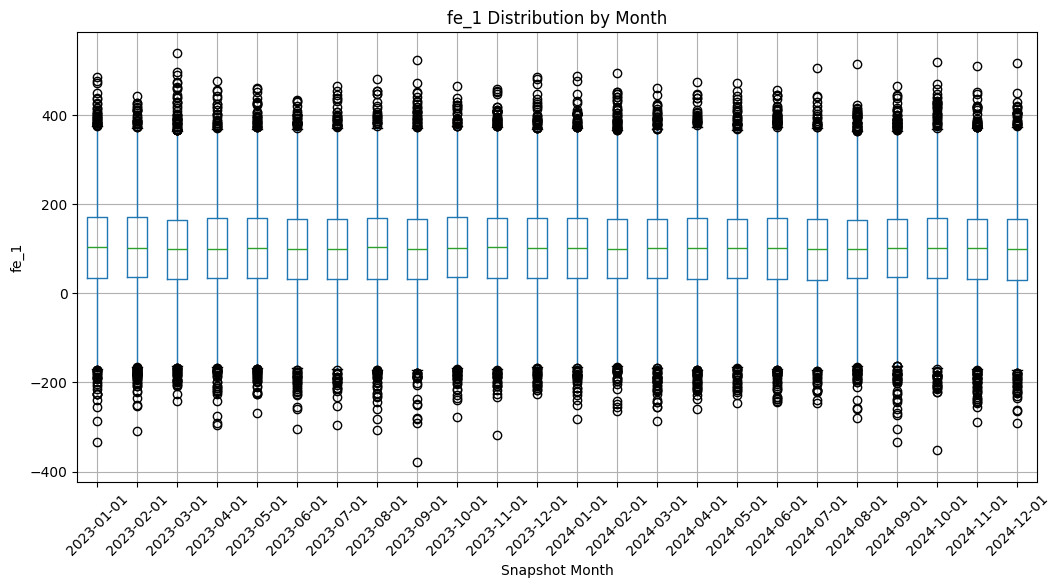

In [71]:
pdf = (
    df
    .select("snapshot_date", "fe_1")
    .toPandas()
)

pdf["snapshot_date"] = pdf["snapshot_date"].astype(str)

pdf.boxplot(
    column="fe_1",
    by="snapshot_date",
    figsize=(12, 6)
)

plt.title("fe_1 Distribution by Month")
plt.suptitle("")
plt.xlabel("Snapshot Month")
plt.ylabel("fe_1")
plt.xticks(rotation=45)
plt.show()

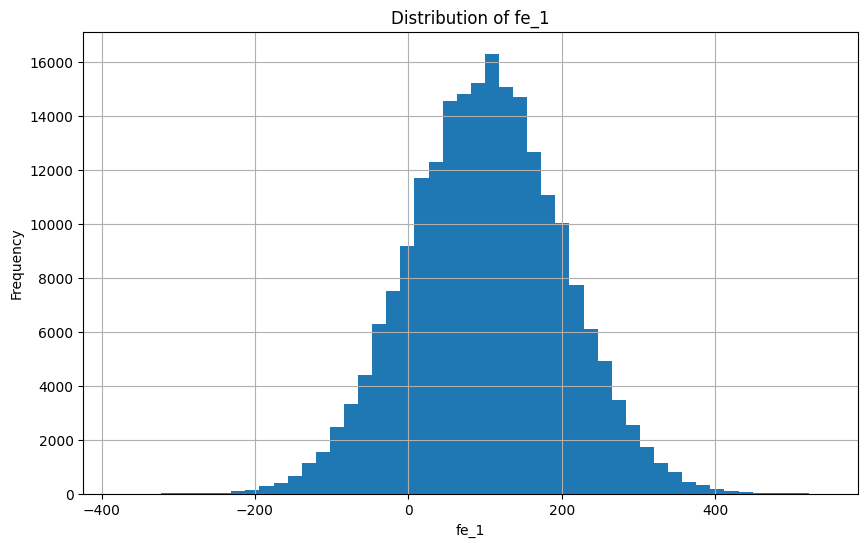

In [76]:
pdf = df.select("fe_1").toPandas()

pdf["fe_1"].hist(bins=50, figsize=(10, 6))

plt.title("Distribution of fe_1")
plt.xlabel("fe_1")
plt.ylabel("Frequency")
plt.show()

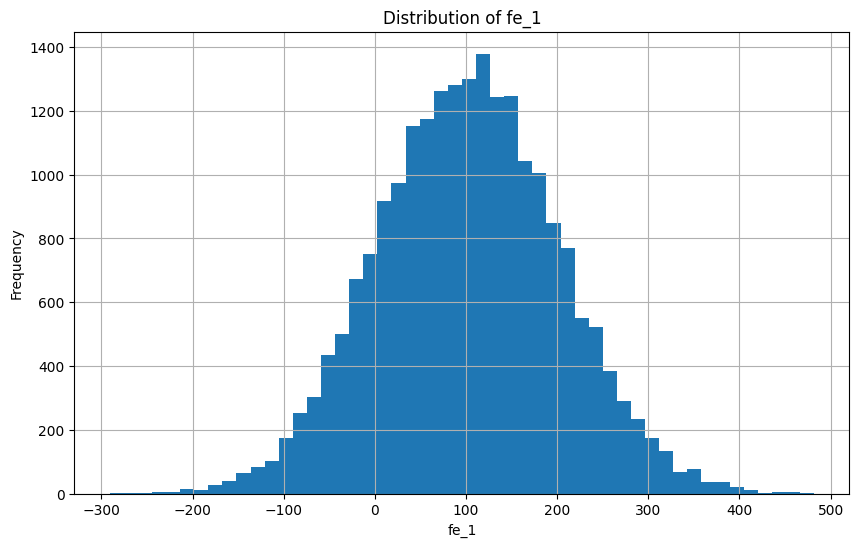

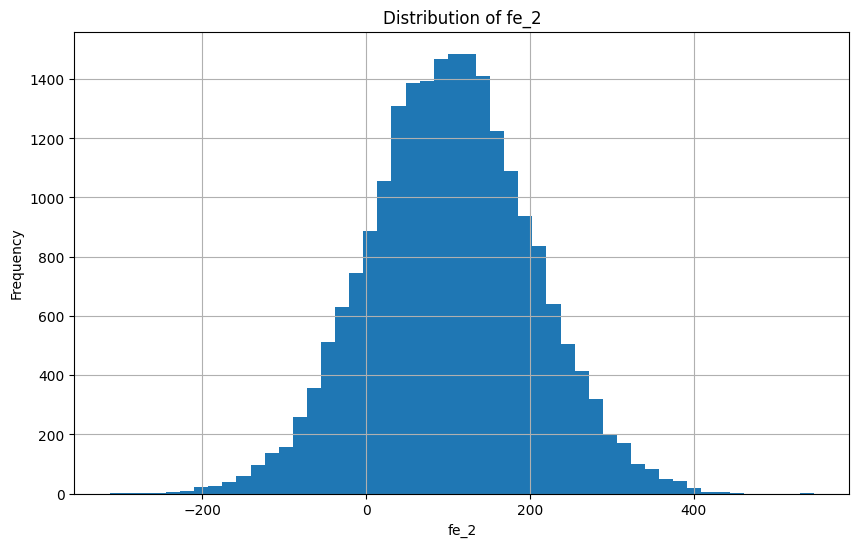

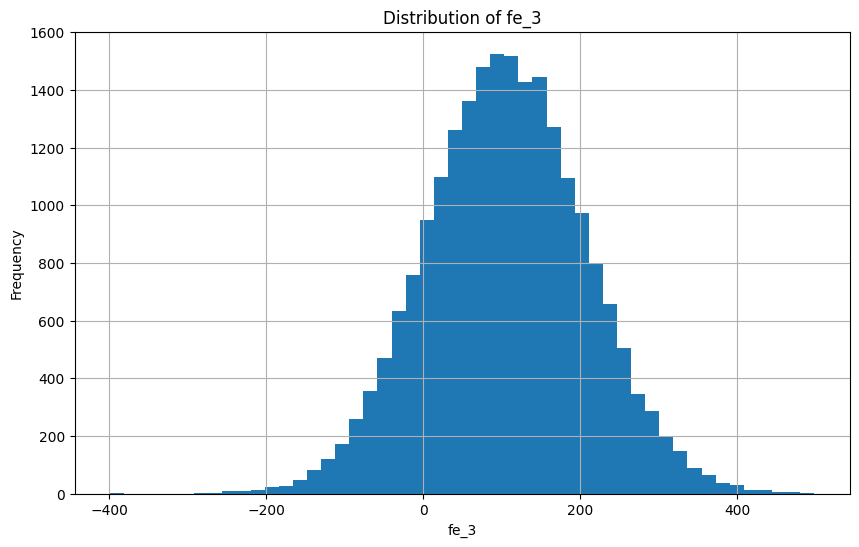

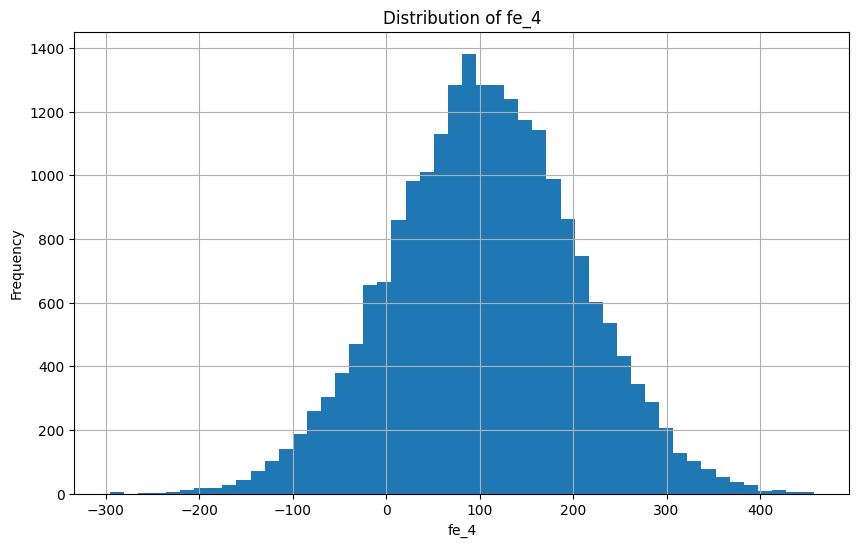

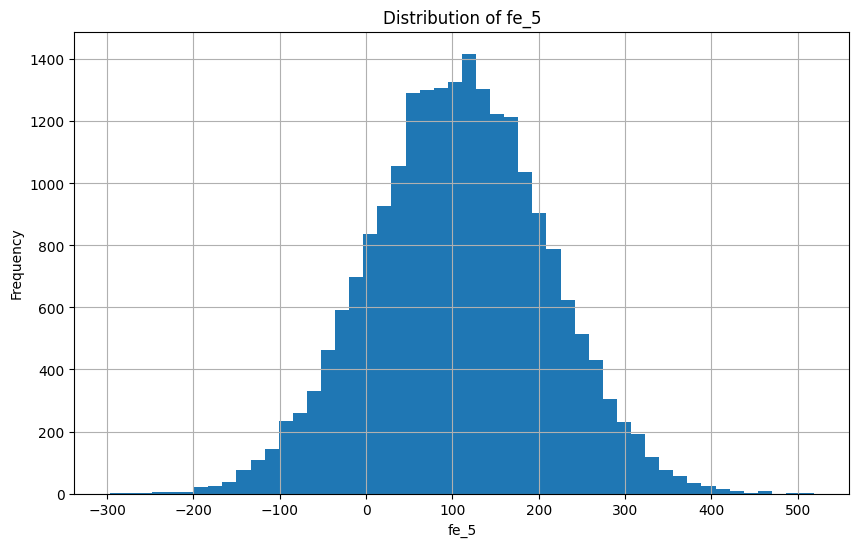

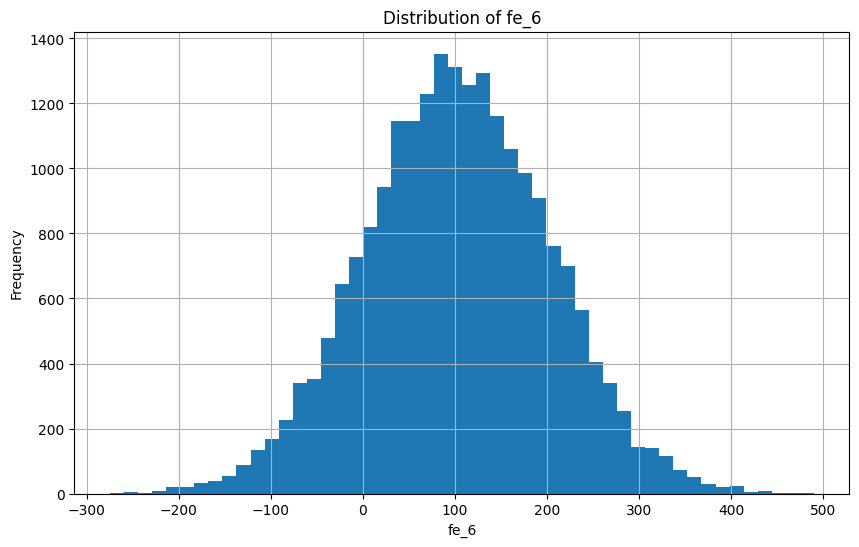

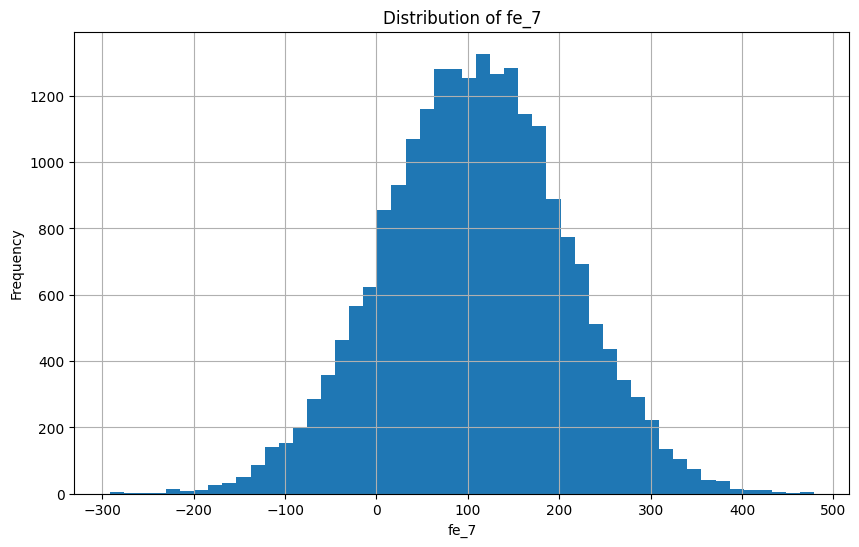

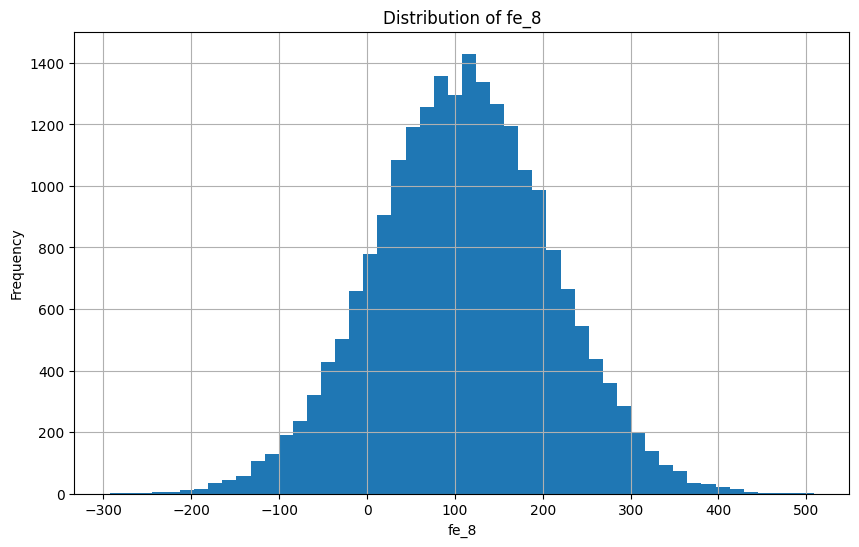

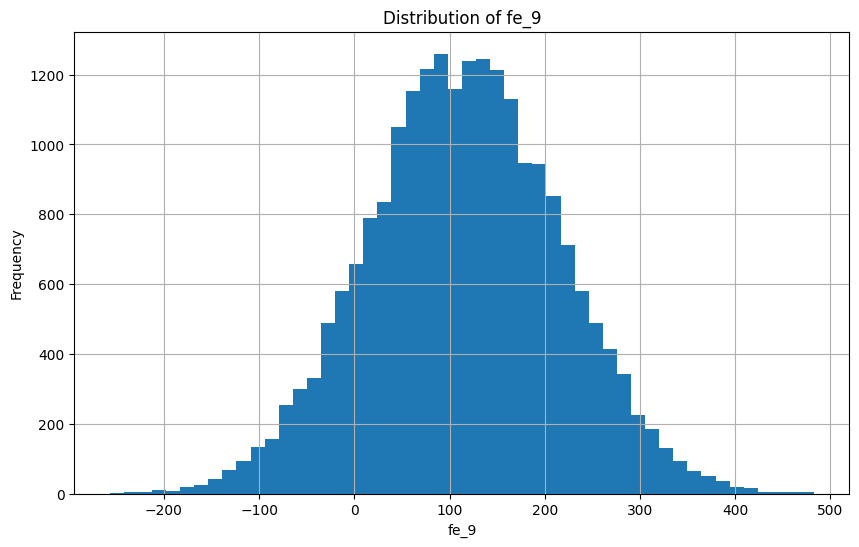

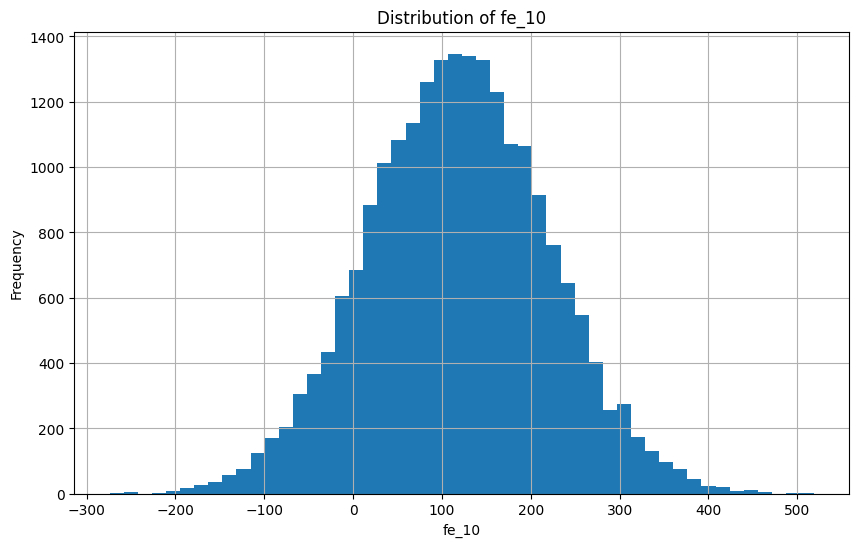

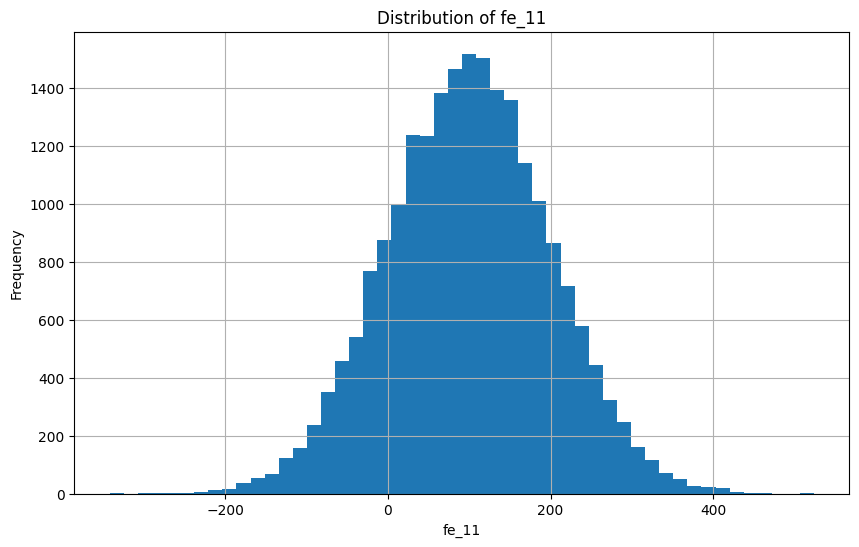

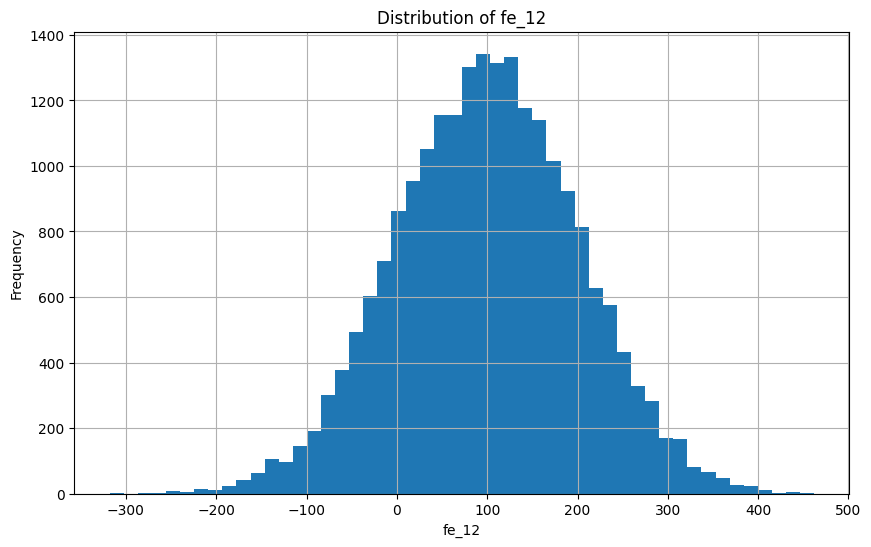

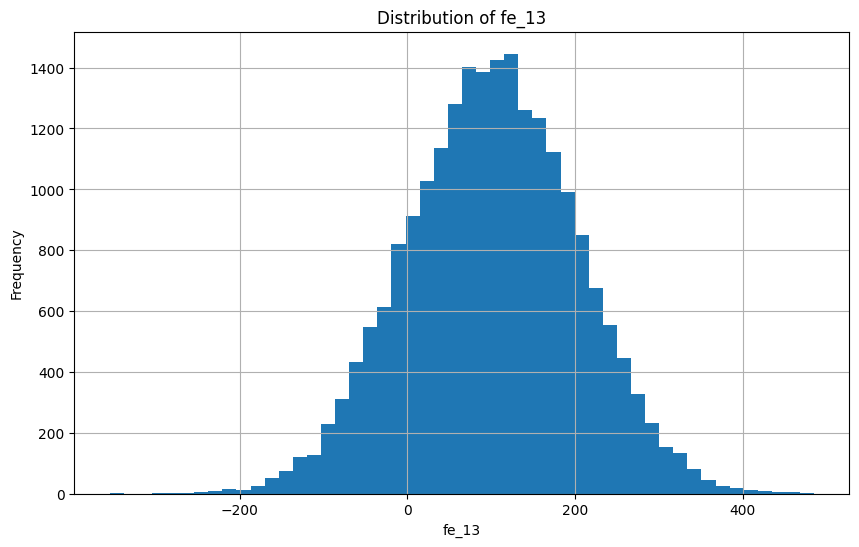

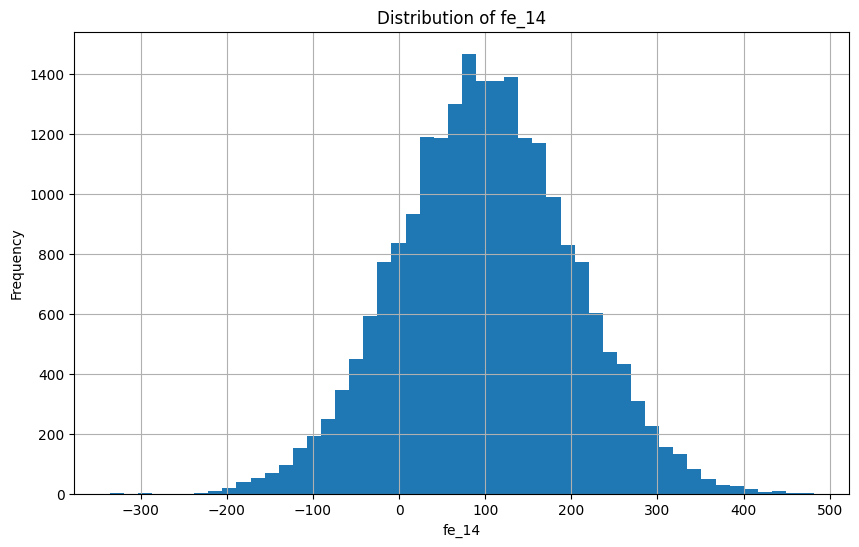

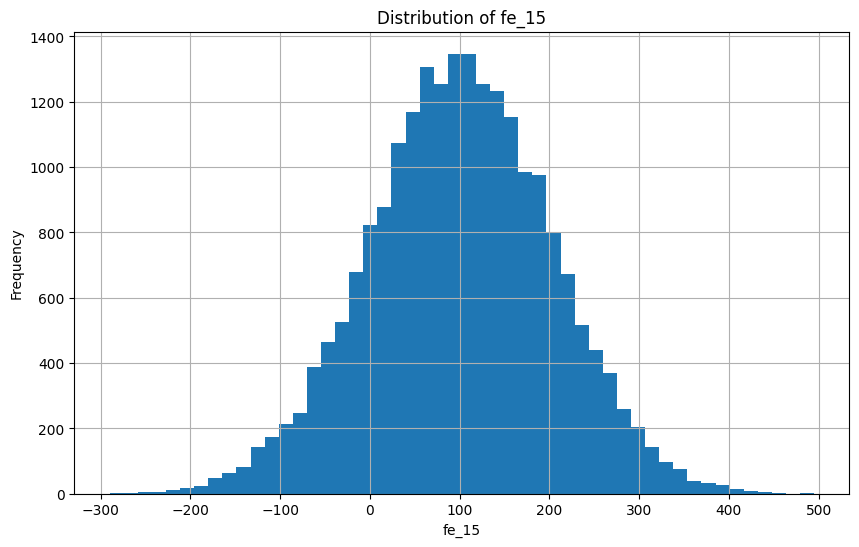

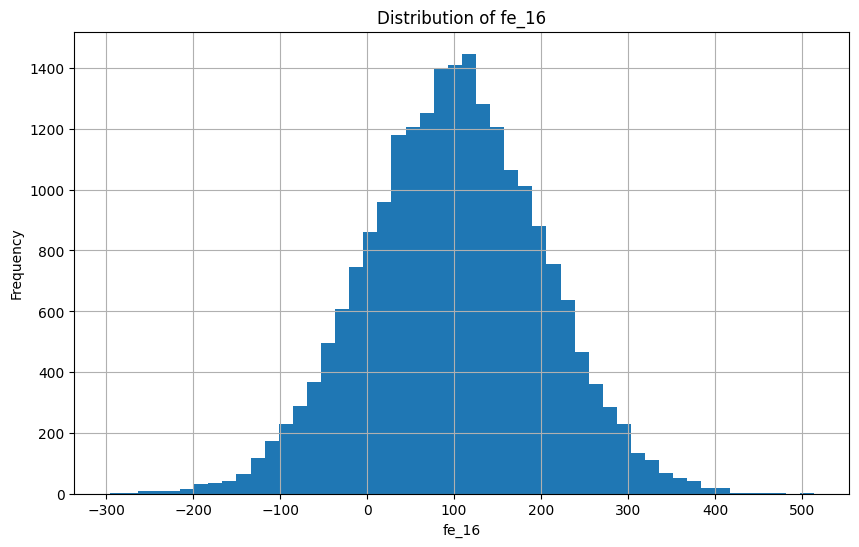

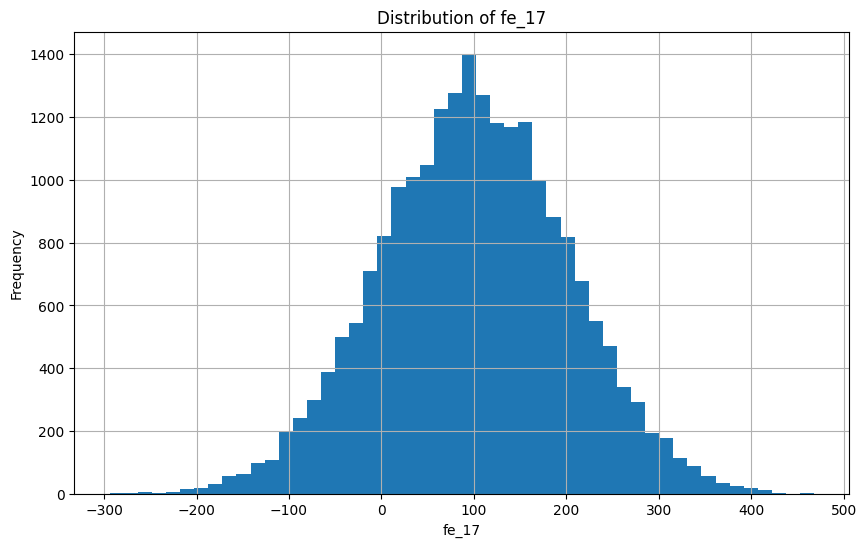

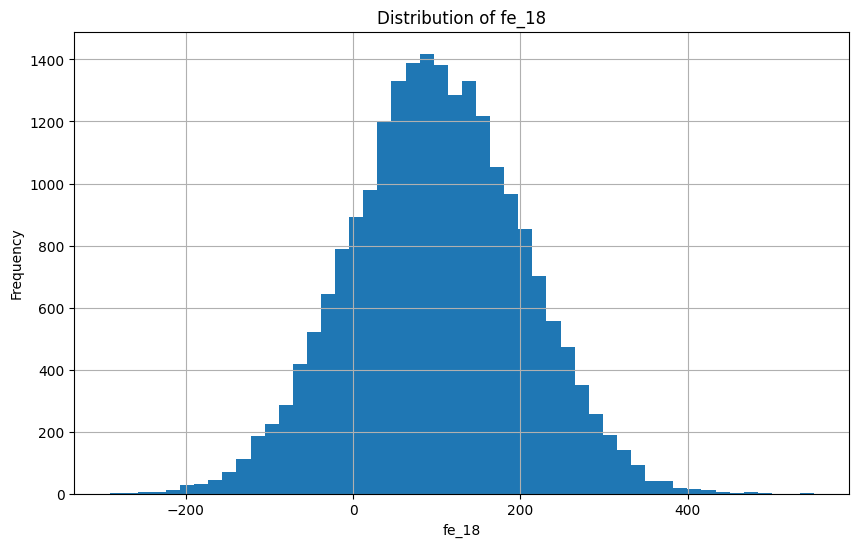

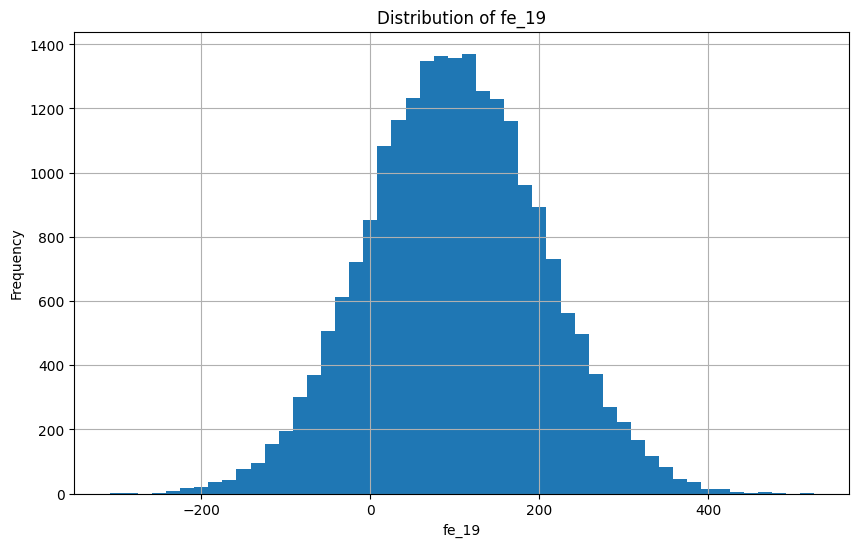

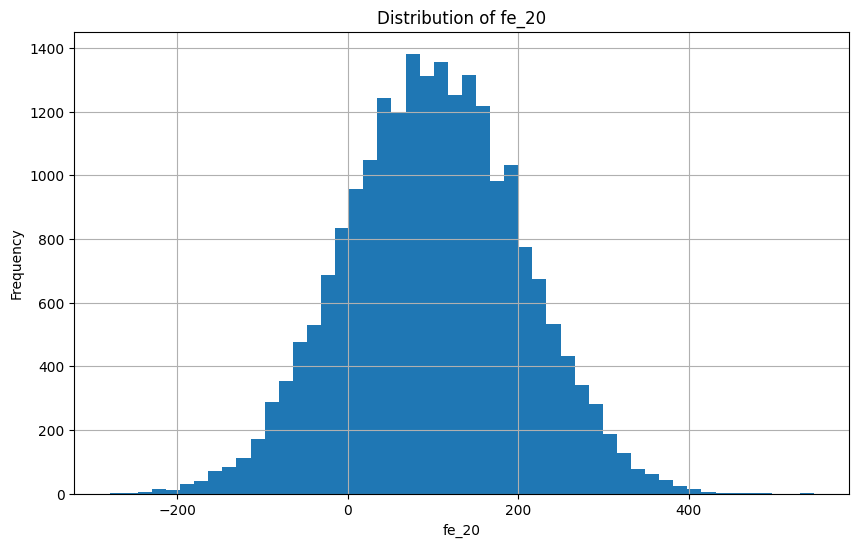

In [77]:
features = [f"fe_{i}" for i in range(1, 21)]

pdf = (
    df
    .select(features)
    .sample(fraction=0.1, seed=42)
    .toPandas()
)

for feature in features:
    plt.figure(figsize=(10, 6))
    pdf[feature].hist(bins=50)

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

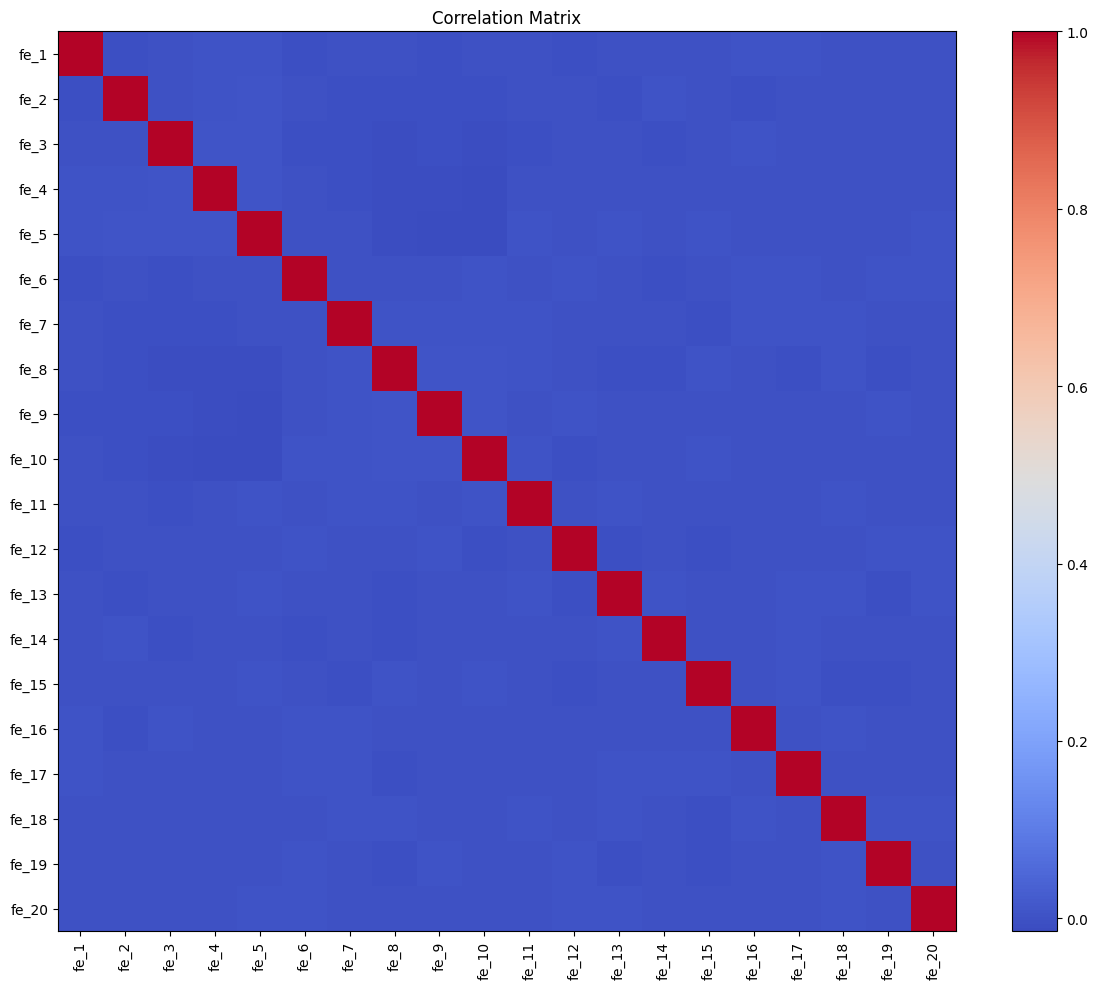

In [79]:
features = [f"fe_{i}" for i in range(1, 21)]

pdf = df.select(features).toPandas()

corr_matrix = pdf.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(range(len(features)), features, rotation=90)
plt.yticks(range(len(features)), features)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [92]:
random_customers = (
    df
    .select("Customer_ID")
    .distinct()
    .orderBy(F.rand(seed=42))
    .limit(3)
)

random_customers.show()

+-----------+
|Customer_ID|
+-----------+
| CUS_0xbc4c|
| CUS_0xb6aa|
| CUS_0xc586|
+-----------+



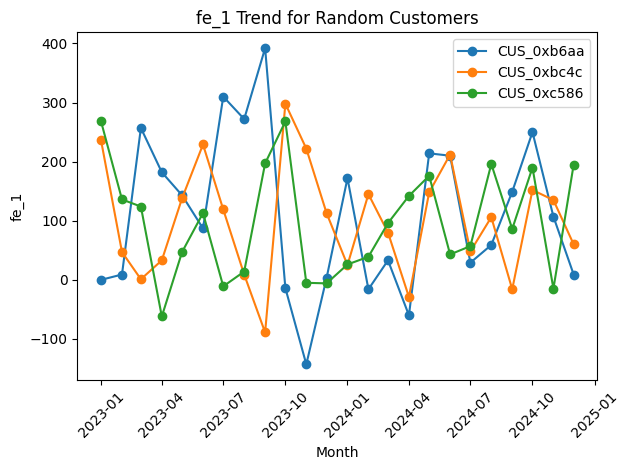

In [93]:
sample_df = (
    df
    .join(random_customers, on="Customer_ID", how="inner")
    .select("Customer_ID", "snapshot_date", "fe_1")
    .orderBy("Customer_ID", "snapshot_date")
)

pdf = sample_df.toPandas()

for customer_id, group in pdf.groupby("Customer_ID"):
    plt.plot(
        group["snapshot_date"],
        group["fe_1"],
        marker="o",
        label=str(customer_id)
    )

plt.xlabel("Month")
plt.ylabel("fe_1")
plt.title("fe_1 Trend for Random Customers")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

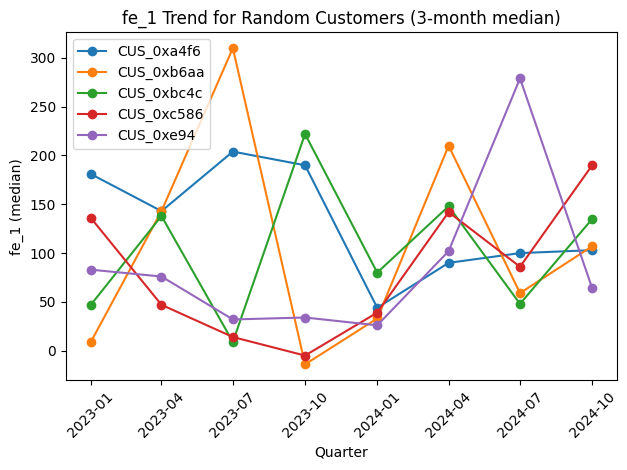

In [84]:
sample_df = (
    df
    .join(random_customers, on="Customer_ID", how="inner")
    .withColumn("period", F.trunc("snapshot_date", "quarter"))
    .groupBy("Customer_ID", "period")
    .agg(F.percentile_approx("fe_1", 0.5).alias("fe_1"))
    .orderBy("Customer_ID", "period")
)

pdf = sample_df.toPandas()

for customer_id, group in pdf.groupby("Customer_ID"):
    plt.plot(group["period"], group["fe_1"], marker="o", label=str(customer_id))

plt.xlabel("Quarter")
plt.ylabel("fe_1 (median)")
plt.title("fe_1 Trend for Random Customers (3-month median)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

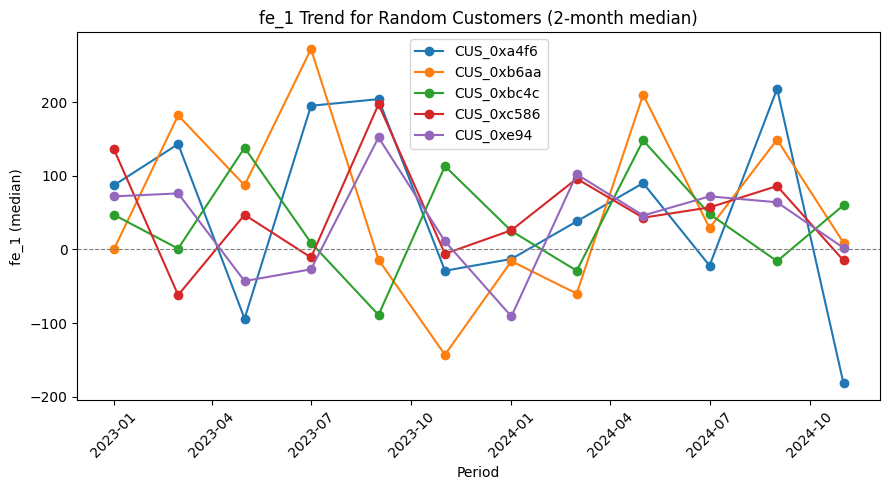

In [89]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

N_MONTHS = 2 # set to 6 for half-year buckets

sample_df = (
    df
    .join(random_customers, on="Customer_ID", how="inner")
    .select("Customer_ID", "snapshot_date", "fe_1")
    .withColumn(
        "period",
        F.add_months(
            F.trunc("snapshot_date", "year"),
            F.floor((F.month("snapshot_date") - 1) / N_MONTHS) * N_MONTHS
        )
    )
    .groupBy("Customer_ID", "period")
    .agg(
        F.percentile_approx("fe_1", 0.5).alias("fe_1_median"),
        F.count("fe_1").alias("n_months")
    )
    .orderBy("Customer_ID", "period")
)

pdf = sample_df.toPandas()

plt.figure(figsize=(9, 5))

for customer_id, group in pdf.groupby("Customer_ID"):
    group = group.sort_values("period")
    plt.plot(
        group["period"],
        group["fe_1_median"],
        marker="o",
        label=str(customer_id)
    )

plt.xlabel("Period")
plt.ylabel("fe_1 (median)")
plt.title(f"fe_1 Trend for Random Customers ({N_MONTHS}-month median)")
plt.xticks(rotation=45)
plt.axhline(0, color="grey", linewidth=0.8, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()

In [91]:
stats = df.groupBy("Customer_ID").agg(
    F.mean("fe_1").alias("cust_mean"),
    F.variance("fe_1").alias("within_var")
)
between_var = stats.select(F.variance("cust_mean")).first()[0]
within_var  = stats.select(F.mean("within_var")).first()[0]
icc = between_var / (between_var + within_var)
icc

0.03991572178664262

In [63]:

within = (df.groupBy("Customer_ID")
            .agg(*[F.stddev(f"fe_{i}").alias(f"fe_{i}_within") for i in range(1, 21)]))
within.show()

+-----------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|Customer_ID|       fe_1_within|       fe_2_within|       fe_3_within|       fe_4_within|       fe_5_within|       fe_6_within|       fe_7_within|       fe_8_within|       fe_9_within|      fe_10_within|      fe_11_within|      fe_12_within|      fe_13_within|      fe_14_within|      fe_15_within|      fe_16_within|      fe_17_within|      fe_18_within|      fe_19_within|      fe_20_within|
+-----------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+---------

## Build gold table for labels

In [4]:
# create bronze datalake
gold_label_store_directory = "datamart/gold/label_store/"
silver_loan_daily_directory = "datamart/silver/loan_daily/"

if not os.path.exists(gold_label_store_directory):
    os.makedirs(gold_label_store_directory)

In [50]:
def process_labels_gold_table(snapshot_date_str, silver_loan_daily_directory, gold_label_store_directory, spark, dpd, mob):
    
    # prepare arguments
    snapshot_date = datetime.strptime(snapshot_date_str, "%Y-%m-%d")
    
    # connect to silver table
    partition_name = "silver_loan_daily_" + snapshot_date_str.replace('-','_') + '.parquet'
    filepath = silver_loan_daily_directory + partition_name
    df = spark.read.parquet(filepath)
    print('loaded from:', filepath, 'row count:', df.count())

    # get customer at mob
    df = df.filter(col("mob") == mob)

    # get label
    df = df.withColumn("label", F.when(col("dpd") >= dpd, 1).otherwise(0).cast(IntegerType()))
    df = df.withColumn("label_def", F.lit(str(dpd)+'dpd_'+str(mob)+'mob').cast(StringType()))

    # select columns to save
    df = df.select("loan_id", "customer_ID", "label", "label_def", "snapshot_date")

    # save gold table - IRL connect to database to write
    partition_name = "gold_label_store_" + snapshot_date_str.replace('-','_') + '.parquet'
    filepath = gold_label_store_directory + partition_name
    print('overwritten to:', filepath, )
    df.write.mode("overwrite").parquet(filepath)
    print('saved to:', filepath, ' row count:', df.count())
    
    return df

In [51]:
# run gold backfill
for date_str in dates_str_lst:
    process_labels_gold_table(date_str, silver_loan_daily_directory, gold_label_store_directory, spark, dpd = 30, mob = 6)


loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_01_01.parquet row count: 530
overwritten to: datamart/gold/label_store/gold_label_store_2023_01_01.parquet
saved to: datamart/gold/label_store/gold_label_store_2023_01_01.parquet  row count: 0


loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_02_01.parquet row count: 1031
overwritten to: datamart/gold/label_store/gold_label_store_2023_02_01.parquet
saved to: datamart/gold/label_store/gold_label_store_2023_02_01.parquet  row count: 0


loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_03_01.parquet row count: 1537
overwritten to: datamart/gold/label_store/gold_label_store_2023_03_01.parquet
saved to: datamart/gold/label_store/gold_label_store_2023_03_01.parquet  row count: 0
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_04_01.parquet row count: 2047
overwritten to: datamart/gold/label_store/gold_label_store_2023_04_01.parquet
saved to: datamart/gold/label_store/gold_label_store_2023_04_01.parquet  row count: 0
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_05_01.parquet row count: 2568
overwritten to: datamart/gold/label_store/gold_label_store_2023_05_01.parquet
saved to: datamart/gold/label_store/gold_label_store_2023_05_01.parquet  row count: 0


loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_06_01.parquet row count: 3085
overwritten to: datamart/gold/label_store/gold_label_store_2023_06_01.parquet
saved to: datamart/gold/label_store/gold_label_store_2023_06_01.parquet  row count: 0


loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_07_01.parquet row count: 3556
overwritten to: datamart/gold/label_store/gold_label_store_2023_07_01.parquet
saved to: datamart/gold/label_store/gold_label_store_2023_07_01.parquet  row count: 530
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_08_01.parquet row count: 4037
overwritten to: datamart/gold/label_store/gold_label_store_2023_08_01.parquet
saved to: datamart/gold/label_store/gold_label_store_2023_08_01.parquet  row count: 501
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_09_01.parquet row count: 4491
overwritten to: datamart/gold/label_store/gold_label_store_2023_09_01.parquet
saved to: datamart/gold/label_store/gold_label_store_2023_09_01.parquet  row count: 506
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_10_01.parquet row count: 4978
overwritten to: datamart/gold/label_store/gold_label_store_2023_10_01.parquet
saved to: datamart/gold/label_store/gold_label_store

...

loaded from: datamart/silver/loan_daily/silver_loan_daily_2025_04_01.parquet row count: 4024
overwritten to: datamart/gold/label_store/gold_label_store_2025_04_01.parquet
saved to: datamart/gold/label_store/gold_label_store_2025_04_01.parquet  row count: 456
loaded from: datamart/silver/loan_daily/silver_loan_daily_2025_05_01.parquet row count: 3526
overwritten to: datamart/gold/label_store/gold_label_store_2025_05_01.parquet
saved to: datamart/gold/label_store/gold_label_store_2025_05_01.parquet  row count: 488


loaded from: datamart/silver/loan_daily/silver_loan_daily_2025_06_01.parquet row count: 3021
overwritten to: datamart/gold/label_store/gold_label_store_2025_06_01.parquet
saved to: datamart/gold/label_store/gold_label_store_2025_06_01.parquet  row count: 515


loaded from: datamart/silver/loan_daily/silver_loan_daily_2025_07_01.parquet row count: 2478
overwritten to: datamart/gold/label_store/gold_label_store_2025_07_01.parquet
saved to: datamart/gold/label_store/gold_label_store_2025_07_01.parquet  row count: 526


loaded from: datamart/silver/loan_daily/silver_loan_daily_2025_08_01.parquet row count: 1985
overwritten to: datamart/gold/label_store/gold_label_store_2025_08_01.parquet
saved to: datamart/gold/label_store/gold_label_store_2025_08_01.parquet  row count: 0


loaded from: datamart/silver/loan_daily/silver_loan_daily_2025_09_01.parquet row count: 1529
overwritten to: datamart/gold/label_store/gold_label_store_2025_09_01.parquet
saved to: datamart/gold/label_store/gold_label_store_2025_09_01.parquet  row count: 0
loaded from: datamart/silver/loan_daily/silver_loan_daily_2025_10_01.parquet row count: 1041
overwritten to: datamart/gold/label_store/gold_label_store_2025_10_01.parquet
saved to: datamart/gold/label_store/gold_label_store_2025_10_01.parquet  row count: 0
loaded from: datamart/silver/loan_daily/silver_loan_daily_2025_11_01.parquet row count: 526
overwritten to: datamart/gold/label_store/gold_label_store_2025_11_01.parquet
saved to: datamart/gold/label_store/gold_label_store_2025_11_01.parquet  row count: 0
loaded from: datamart/silver/loan_daily/silver_loan_daily_2025_12_01.parquet row count: 0
overwritten to: datamart/gold/label_store/gold_label_store_2025_12_01.parquet
saved to: datamart/gold/label_store/gold_label_store_2025_12_0

In [52]:
folder_path = gold_label_store_directory
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)
print("row_count:",df.count())

df.show()

row_count: 12500
+--------------------+-----------+-----+----------+-------------+
|             loan_id|customer_ID|label| label_def|snapshot_date|
+--------------------+-----------+-----+----------+-------------+
|CUS_0x10ac_2024_0...| CUS_0x10ac|    0|30dpd_6mob|   2025-02-01|
|CUS_0x10c5_2024_0...| CUS_0x10c5|    1|30dpd_6mob|   2025-02-01|
|CUS_0x1145_2024_0...| CUS_0x1145|    1|30dpd_6mob|   2025-02-01|
|CUS_0x11ac_2024_0...| CUS_0x11ac|    0|30dpd_6mob|   2025-02-01|
|CUS_0x122c_2024_0...| CUS_0x122c|    0|30dpd_6mob|   2025-02-01|
|CUS_0x1274_2024_0...| CUS_0x1274|    1|30dpd_6mob|   2025-02-01|
|CUS_0x1288_2024_0...| CUS_0x1288|    1|30dpd_6mob|   2025-02-01|
|CUS_0x12cc_2024_0...| CUS_0x12cc|    1|30dpd_6mob|   2025-02-01|
|CUS_0x1338_2024_0...| CUS_0x1338|    0|30dpd_6mob|   2025-02-01|
|CUS_0x1370_2024_0...| CUS_0x1370|    1|30dpd_6mob|   2025-02-01|
|CUS_0x1378_2024_0...| CUS_0x1378|    1|30dpd_6mob|   2025-02-01|
|CUS_0x139b_2024_0...| CUS_0x139b|    0|30dpd_6mob|   2025-

## Build Feature store

In [53]:
gold_features_store_directory = "datamart/gold/features_store/"
silver_loan_daily_directory = "datamart/silver/loan_daily/"
silver_customer_directory = "datamart/silver/customers/"
silver_financials_directory = "datamart/silver/financials/"
silver_clickstream_directory = "datamart/silver/clickstream/"

if not os.path.exists(gold_features_store_directory):
    os.makedirs(gold_features_store_directory)

In [ ]:
def process_features_gold_table(snapshot_date_str, silver_loan_daily_directory, 
                                silver_customer_directory, 
                                silver_financials_directory, 
                                silver_clickstream_directory,
                                gold_features_store_directory, spark):
    
    snapshot_date = datetime.strptime(snapshot_date_str, "%Y-%m-%d")
    silver_loan_daily_filepath = silver_loan_daily_directory +  "silver_loan_daily_" + snapshot_date_str.replace('-','_') + '.parquet'
    loan_df = spark.read.parquet(silver_loan_daily_filepath)
    print('loaded from:', silver_loan_daily_filepath, 'row count:', loan_df.count())

    customers_files_list = [silver_customer_directory+os.path.basename(f) for f in glob.glob(os.path.join(silver_customer_directory, '*'))]
    customer_df = spark.read.option("header", "true").parquet(*customers_files_list)    

    customer_df = customer_df.drop("name", "ssn")
    print('loaded from:', silver_customer_directory, 'row count:', customer_df.count())

    financials_files_list = [silver_financials_directory+os.path.basename(f) for f in glob.glob(os.path.join(silver_financials_directory, '*'))]
    financials_df = spark.read.option("header", "true").parquet(*financials_files_list)
    financials_df = financials_df.drop("credit_history_age")
    print('loaded from:', silver_financials_directory, 'row count:', financials_df.count())
    sliver_clickstream_filepath = silver_clickstream_directory +  "silver_clickstream_" + snapshot_date_str.replace('-','_') + '.parquet'
    clickstream_df = spark.read.parquet(sliver_clickstream_filepath)
    print('loaded from:', sliver_clickstream_filepath, 'row count:', clickstream_df.count())


    df = loan_df.join(customer_df.drop("snapshot_date"), on=["customer_ID"], how="left")
    df = df.join(financials_df.drop("snapshot_date"), on=["customer_ID"], how="left")
    df = df.join(clickstream_df, on=["customer_ID", "snapshot_date"], how="left")

    partition_name = "gold_features_store_" + snapshot_date_str.replace('-','_') + '.parquet'
    filepath = gold_features_store_directory + partition_name
    print('overwritten to:', filepath)
    df.write.mode("overwrite").parquet(filepath)
    print('saved to:', filepath, ' row count:', df.count())
    print("end======================")

    return df

In [57]:
for date_str in dates_str_lst[0:10]:
    process_features_gold_table(date_str, silver_loan_daily_directory,
                                silver_customer_directory,
                                silver_financials_directory,
                                silver_clickstream_directory,
                                gold_features_store_directory,
                                spark)


loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_01_01.parquet row count: 530
loaded from: datamart/silver/customers/ row count: 12500
loaded from: datamart/silver/financials/ row count: 12500
loaded from: datamart/silver/clickstream/silver_clickstream_2023_01_01.parquet row count: 8974
overwritten to: datamart/gold/features_store/gold_features_store_2023_01_01.parquet
saved to: datamart/gold/features_store/gold_features_store_2023_01_01.parquet  row count: 530
end======================
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_02_01.parquet row count: 1031
loaded from: datamart/silver/customers/ row count: 12500
loaded from: datamart/silver/financials/ row count: 12500
loaded from: datamart/silver/clickstream/silver_clickstream_2023_02_01.parquet row count: 8974
overwritten to: datamart/gold/features_store/gold_features_store_2023_02_01.parquet
saved to: datamart/gold/features_store/gold_features_store_2023_02_01.parquet  row count: 1031
end=========

In [60]:
#customers_files_list = [silver_customer_directory+os.path.basename(f) for f in glob.glob(os.path.join(silver_customer_directory, '*'))]
customers_df = spark.read.option("header", "true").parquet("datamart/silver/customers/silver_customers_2023_01_01.parquet")    

clickstream_df = spark.read.parquet("datamart/silver/clickstream/silver_clickstream_2023_01_01.parquet")
join_df = clickstream_df.join(customers_df.drop("snapshot_date"), on=["customer_ID"], how="left")
join_df.write.mode("overwrite").parquet("gold_features_store_2023_01_01.parquet")
